In [3]:
import numpy as np
import time
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from networks import regular_lattice, influencer_network, directed_lattice
import matrix_utils as mu
%load_ext autoreload
%autoreload 2

done


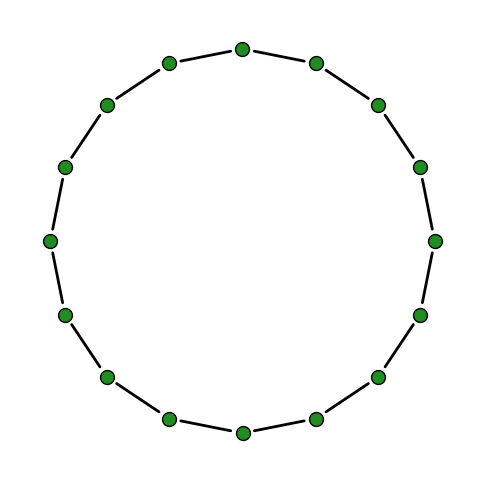

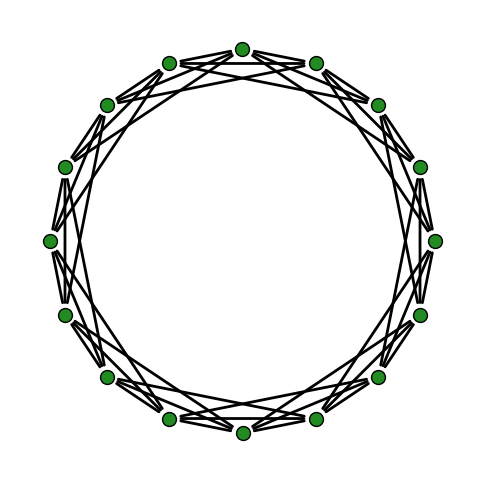

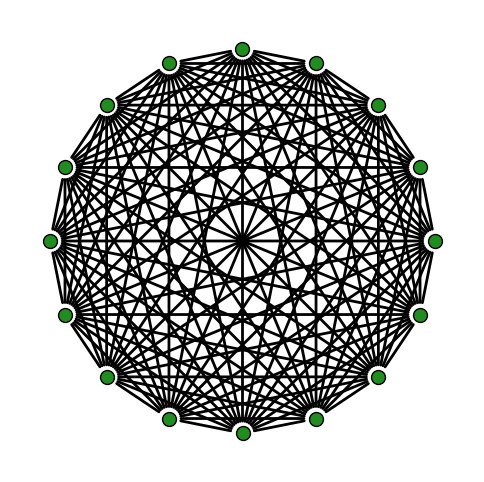

In [14]:
# Create graph from adjacency matrix

def run(n, save=False):
    def draw(A, degree, highlight=[]):
        #clear_output(wait=True)
        G = nx.from_numpy_array(A, create_using=nx.Graph)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(6, 6))

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[i for i in range(n) if i not in highlight],
            #arrowstyle='-|>',
            node_color="forestgreen",
            node_size=100,
            edgecolors="black",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=highlight,
            #arrowstyle='-|>',
            node_color="lime",
            node_size=2*40,
            edgecolors="black",
        )
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=True,
            edgelist=list(G.edges()),
            arrowstyle=None,
            edge_color="black",
            arrowsize=0,
            width=2
        )
        plt.axis("off")
        plt.axis("equal")
        if not save:
            plt.show()
        else:
             plt.savefig(f"graph_{degree}.svg", format="svg", bbox_inches="tight", transparent=True)
    degrees = [2,6,16]
    for degree in degrees:
        A = regular_lattice(n, degree)
        conn = mu.algebraic_connectivity(A)
        draw(A, degree, highlight=[])
        
        if not save:
            time.sleep(1)
    print("done")
    
run(16,save=True)

done


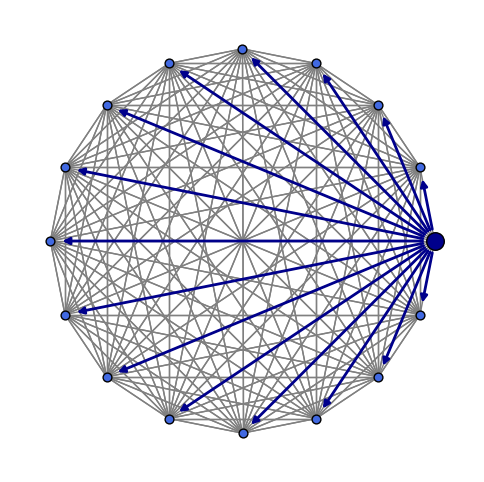

In [59]:
# Create graph from adjacency matrix

def run(n, save=False):
    def draw(A, d, highlight=[]):
        #clear_output(wait=True)
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(6, 6))

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[i for i in range(n+d) if i not in highlight],
            #arrowstyle='-|>',
            node_color="royalblue",
            node_size=40,
            edgecolors="black",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=highlight,
            #arrowstyle='-|>',
            node_color="darkblue",
            node_size=4*40,
            edgecolors="black",
        )
        E = list(G.edges)
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=False,
            edgelist=[(a,b) for a,b in E if a != 0],
            #arrowstyle='-|>',
            edge_color="grey",
            #arrowsize=10,
            width=1
        )
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=True,
            edgelist=[(a,b) for a,b in E if a == 0],
            arrowstyle='-|>',
            edge_color="darkblue",
            arrowsize=10,
            width=2
        )
        plt.axis("off")
        plt.axis("equal")
        plt.axis("equal")
        if not save:
            plt.show()
        else:
            plt.savefig(f"id.svg", format="svg", bbox_inches="tight", transparent=True)

    G = nx.complete_graph(n, nx.DiGraph)
    #G = nx.star_graph(n, nx.DiGraph)
    A = nx.to_numpy_array(G)
    #A = np.eye(n)
    draw(A, 0, [0])        
    print("done")
    
run(16, save=True)

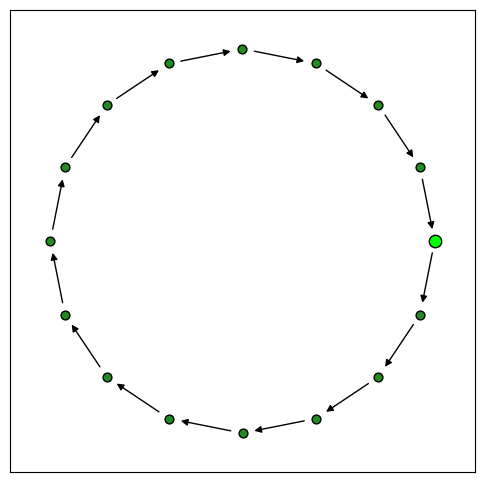

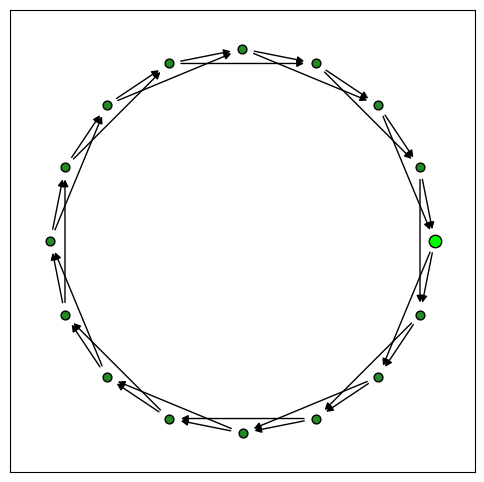

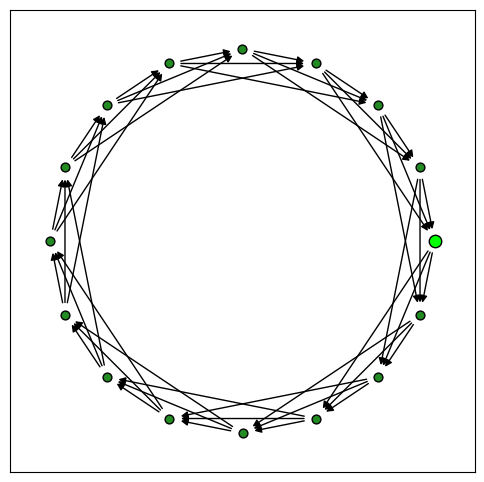

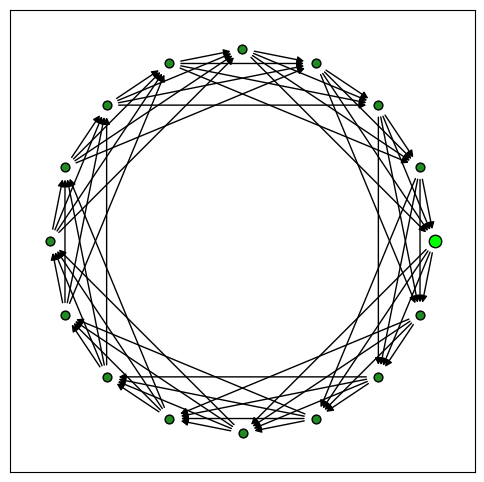

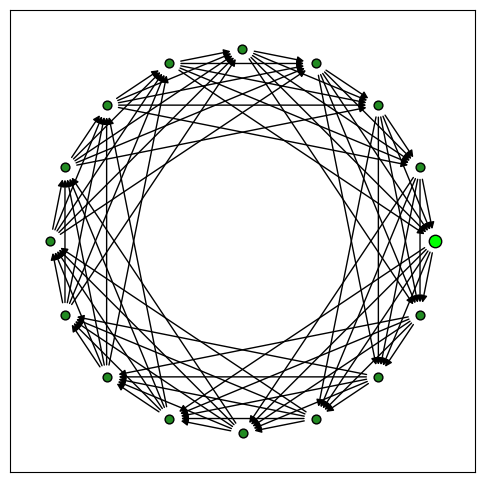

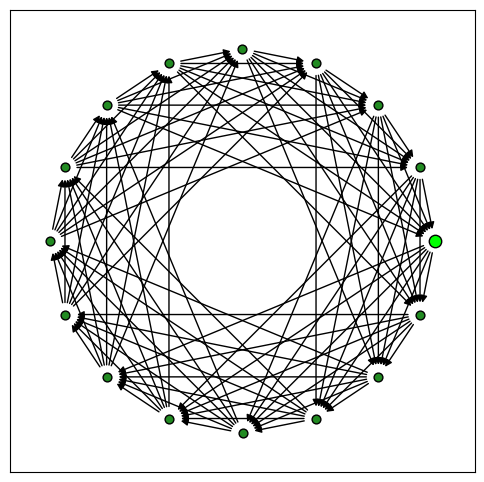

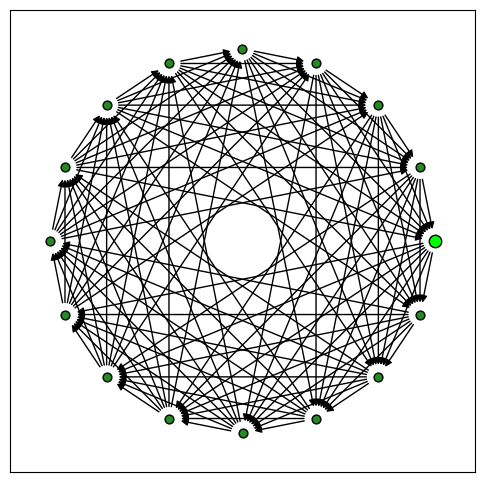

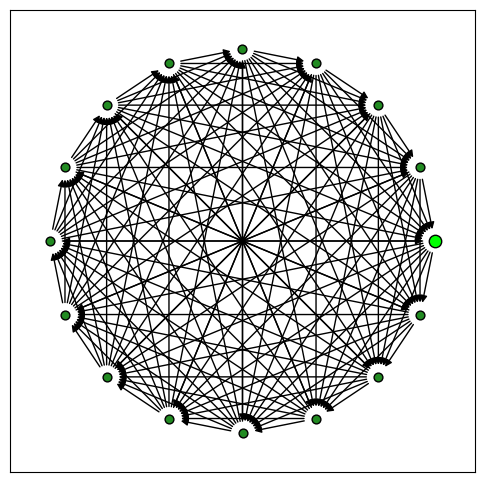

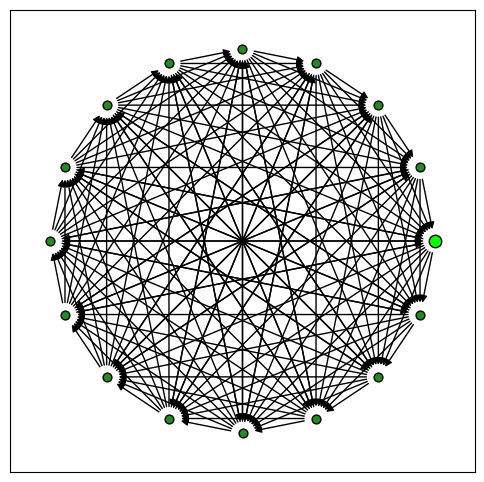

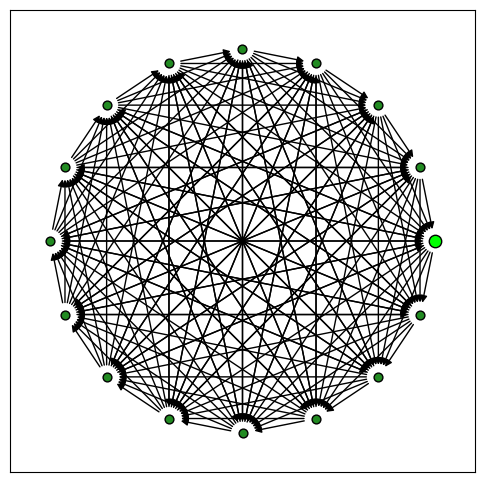

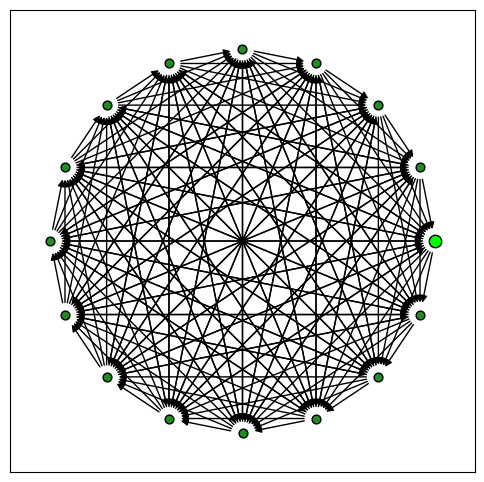

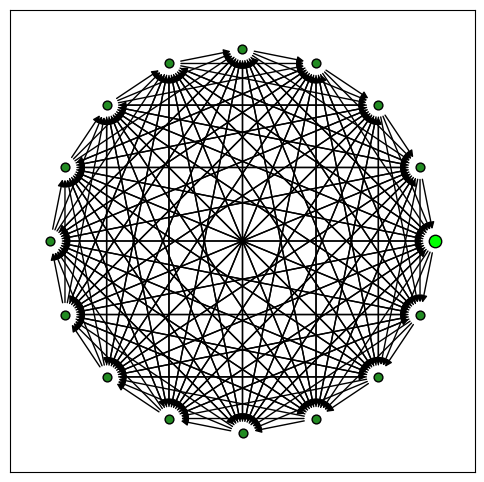

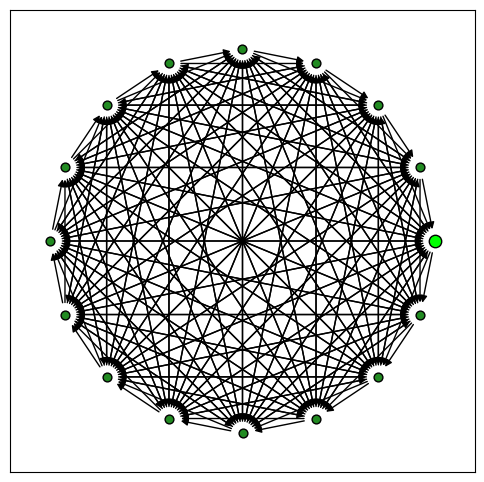

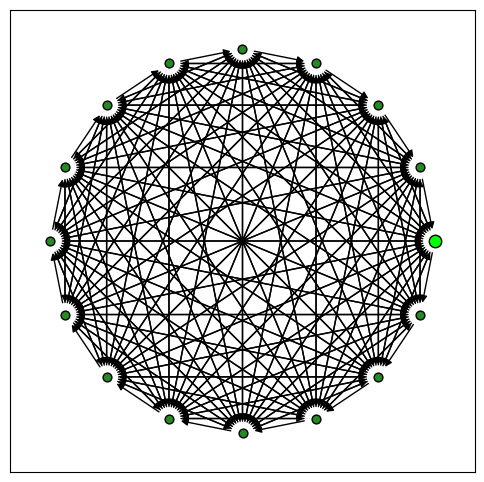

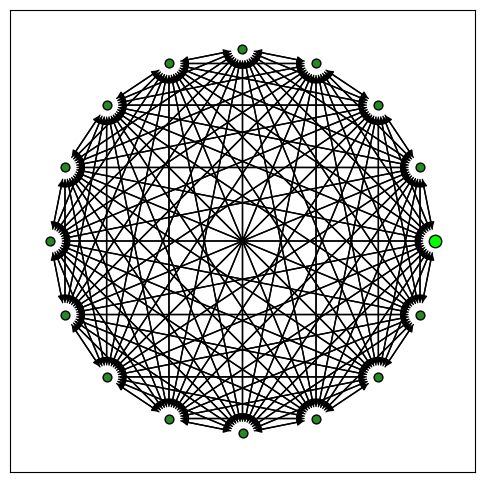

done


In [9]:
# Create graph from adjacency matrix

def run(n, save=False):
    def draw(A, highlight=[]):
        #clear_output(wait=True)
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)
        pos = nx.circular_layout(G)
        plt.figure(figsize=(6, 6))

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[i for i in range(n) if i not in highlight],
            #arrowstyle='-|>',
            node_color="forestgreen",
            node_size=40,
            edgecolors="black",
        )
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=highlight,
            #arrowstyle='-|>',
            node_color="lime",
            node_size=2*40,
            edgecolors="black",
        )
        nx.draw_networkx_edges(
            G,
            pos,
            arrows=True,
            edgelist=list(G.edges()),
            arrowstyle='-|>',
            edge_color="black",
            arrowsize=10
        )
        plt.axis("equal")
        if not save:
            plt.show()
        else:
            plt.savefig(

    f"pngs/plot{degree}.png",
    format="png",
    transparent=True,
    bbox_inches="tight"

)
    for out_degree in [i for i in range(1,n)]:
        A = directed_lattice(n, out_degree)
        draw(A.T, highlight=[0])
        
        time.sleep(1)
        if out_degree == n:
            break
    print("done")
    
run(16)